In [1]:
import numpy as np
import scvelo as scv
import scanpy as sc
import os
import string
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
import scrich as ri

In [2]:
import warnings
warnings.simplefilter("ignore", DeprecationWarning)

In [40]:
adata = sc.read_h5ad('Visium_D14_imputed.h5ad')

In [41]:
adata

AnnData object with n_obs × n_vars = 1967 × 9836
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'percent.mito', 'Spatial_snn_res.1', 'seurat_clusters', 'scanorama_snn_res.1', 'Cardiomyocytes-1', 'Cardiomyocytes-2', 'Immature.myocardial.cells', 'Valve.cells', 'Macrophages', 'Fibroblast.cells', 'Erythrocytes', 'Endocardial.cells', 'MT-enriched.cardiomyocytes', 'Epi-epithelial.cells', 'Vascular.endothelial.cells', 'TMSB4X.high.cells', 'Epi-mesenchymal.cells', 'Dendritic.cells', 'Mural.cells', 'max', 'celltype_prediction_max', 'celltype_prediction', 'celltype_prediction_mode', 'region', 'n_counts', 'velocity_self_transition'
    var: 'gene_ids', 'n_cells', 'gene_count_corr', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'celltype_prediction_colors', 'neighbors', 'pca', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_pca', 'X_umap', 'X_xy_loc'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'spliced', 'unspliced', 'variance_ve

In [42]:
ri.tl.pathways_overview(adata)

Scanning for cell-cell communication pathways...
Identified 55 pathways with at least one Receptor and one Ligand detected


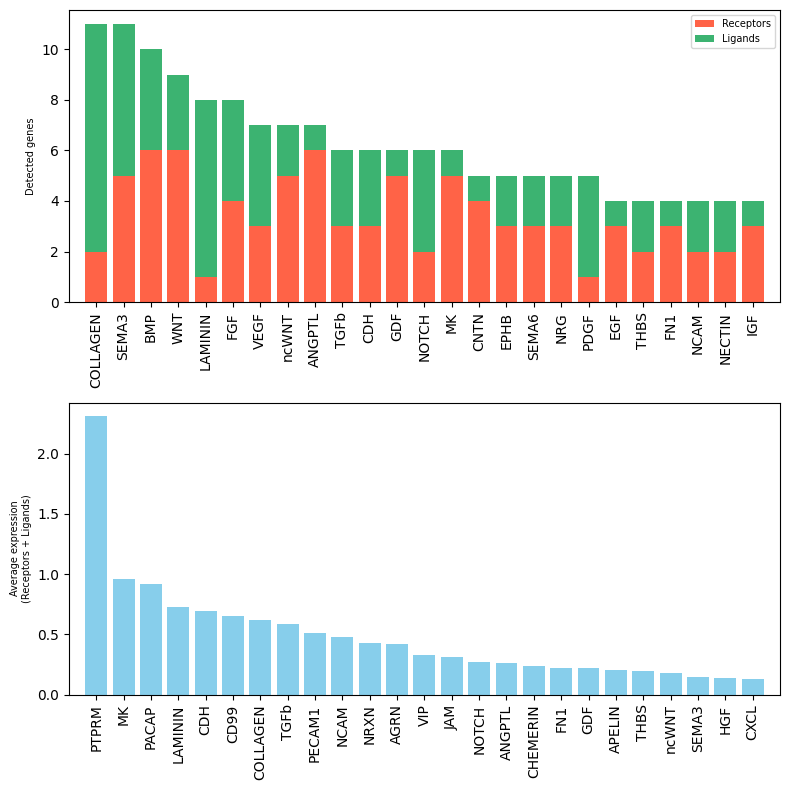

In [43]:
ri.pl.pathways_overview(adata, top=25, ticksize=10, savefig=False, showfig=True)

In [44]:
ri.tl.all_path_sim(adata, 'celltype_prediction', method='expression', pathways_to_use=20, target=False, neighbor_average=True, print_info=True)

['PTPRM', 'MK', 'PACAP', 'LAMININ', 'CDH', 'CD99', 'COLLAGEN', 'TGFb', 'PECAM1', 'NCAM', 'NRXN', 'AGRN', 'VIP', 'JAM', 'NOTCH', 'ANGPTL', 'CHEMERIN', 'FN1', 'GDF', 'APELIN']
Analyzing the PTPRM pathway...
running clustering
Running clustering with nsim=5, kmin=3, kmax=6
clustering #1 with k=3
clustering #2 with k=3
clustering #3 with k=3
clustering #4 with k=3
clustering #5 with k=3
clustering #1 with k=4
clustering #2 with k=4
clustering #3 with k=4
clustering #4 with k=4
clustering #5 with k=4
clustering #1 with k=5
clustering #2 with k=5
clustering #3 with k=5
clustering #4 with k=5
clustering #5 with k=5
clustering #1 with k=6
clustering #2 with k=6
clustering #3 with k=6
clustering #4 with k=6
clustering #5 with k=6
finished sim_mat for PTPRM, starting spectral analysis

The optimal number of clusters is 3
running consensus
Analyzing the MK pathway...
running clustering
Running clustering with nsim=5, kmin=3, kmax=6
clustering #1 with k=3
clustering #2 with k=3
clustering #3 with 

In [45]:
ri.tl.permutation_testing(adata, key='celltype_prediction')

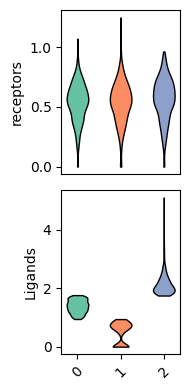

In [46]:
ri.pl.mode_violin(adata, 'MK_modes', savefig=False, showfig=True)

In [47]:
ri.tl.rename_cells(adata, {'Immature myocardial cells': 'Imm myo',
                               'TMSB4X high cells': 'TMSB4 high',
                               'Endocardial cells': 'Endo',
                               'Erythrocytes': 'Eryth',
                               'Epi-epithelial cells': 'Epi',
                               'Vascular endothelial cells': 'VE',
                               'Macrophages': 'Macro',
                               'Cardiomyocytes-1': 'Cardio-1',
                               'Mural cells': 'Mural',
                               'Cardiomyocytes-2': 'Cardio-2',
                               'Valve cells': 'Valve',
                               'Fibroblast cells': 'Fibr'}, key='celltype_prediction')

In [48]:
ri.tl.rename_modes(adata, 'MK', {0: 'Weak Sen/Rec', 1: 'Rec', 2: 'Sen/Rec'})

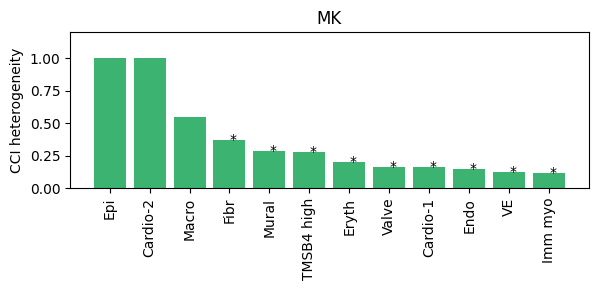

In [49]:
ri.pl.single_pathway_heterogeneity(adata, 'MK', 'celltype_prediction', savefig=False, showfig=True)

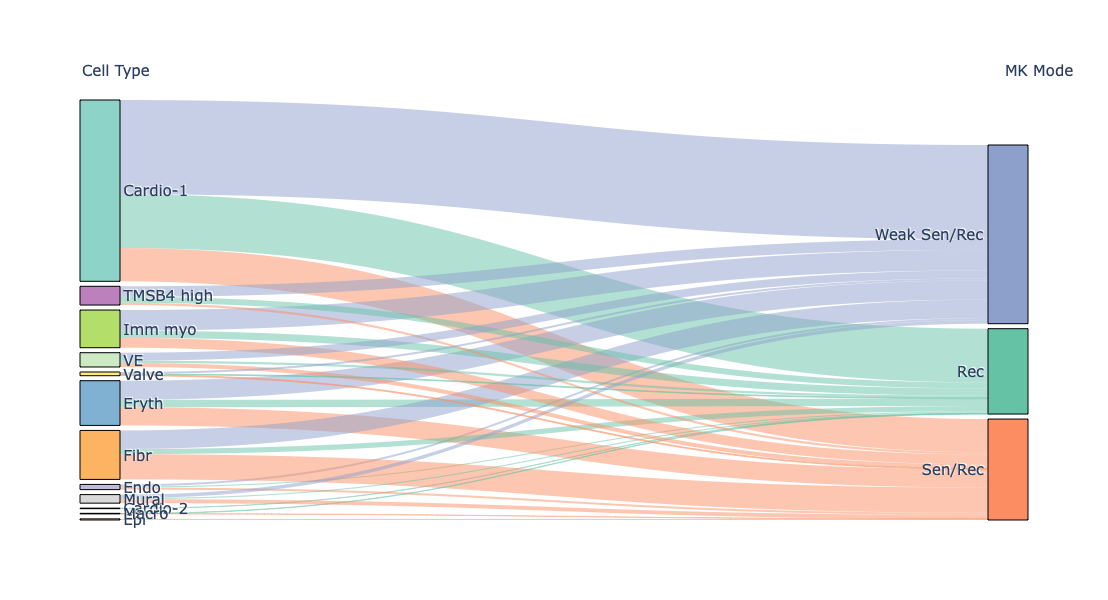

In [50]:
ri.pl.alluvial_onepath(adata, 'MK', 'celltype_prediction', savefig=False, showfig=True)

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


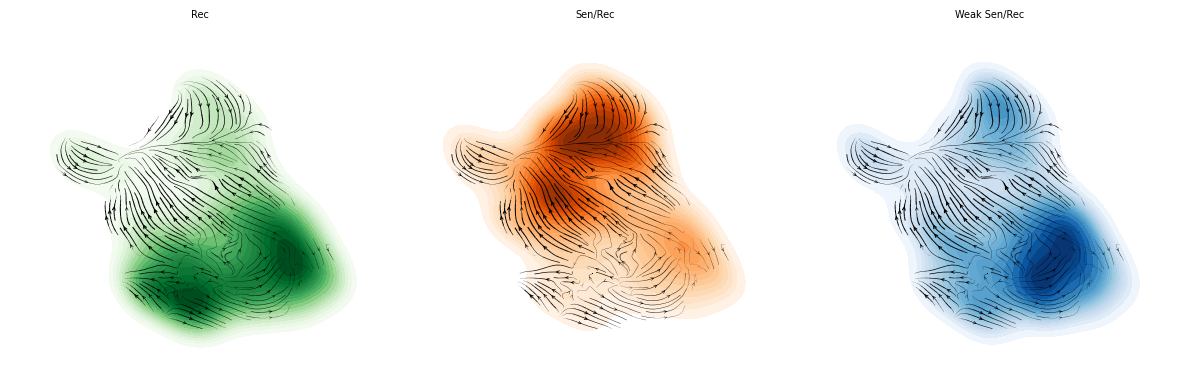

In [51]:
ri.pl.plot_maps(adata, 'MK', savefig=False, showfig=True)

Specific code to compute a CCC heterogeneity score for spatial transcriptomics:

In [53]:
p = 'MK'

modes = np.asarray(adata.obs[p + '_modes'])

conn = adata.obsp['connectivities']
het = np.zeros(modes.size)

for i in range(modes.size):
    neigh_indices = conn[i].indices
    
    if neigh_indices.size == 0:
        continue
        
    neigh_modes = modes[neigh_indices]

    het[i] = float(np.sum(neigh_modes == modes[i])) / neigh_modes.size

adata.obs[p + '_het'] = het

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_xy_loc', embedded velocity vectors (adata.obsm)


Text(0.5, 1.0, 'MK spatial heterogeneity')

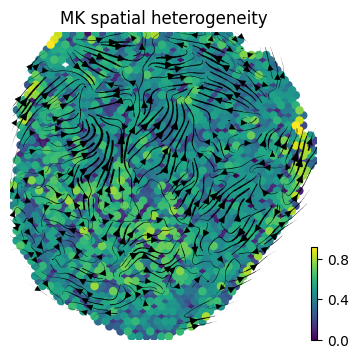

In [54]:
fig = plt.figure(figsize=(5, 4))
ax = plt.subplot2grid((4, 5), (0, 0), rowspan=4, colspan=4)
scv.pl.velocity_embedding_stream(adata, basis='X_xy_loc', color=p+'_het', size=150, alpha=1, ax=ax, show=False)
ax.set_title('MK spatial heterogeneity')